#**Step 1: Installed Required Libraries**

In [ ]:
!pip install cdsapi xarray netCDF4 cartopy geopandas rasterio

import cdsapi
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import geopandas as gpd
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

print("All libraries installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 93.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 60.1 MB/s eta 0:00:00
All libraries installed!


#**Step 2: CDS API Setup**

In [ ]:
import os

full_api_key = "4403735f-ae7a-47cb-be0c-430030415954"

# Created the config file
config_path = os.path.expanduser('~/.cdsapirc')

with open(config_path, 'w') as f:
    f.write("url: https://cds.climate.copernicus.eu/api\n")
    f.write(f"key: {full_api_key}\n")

if os.path.exists(config_path):
    print(" CDS API configuration file created successfully!")
    print(f" Location: {config_path}")
    print(f" {full_api_key[:10]}...")
else:
    print(" Error: Configuration file not created")

 CDS API configuration file created successfully!
 Location: /root/.cdsapirc
 4403735f-a...


In [ ]:
# TEST: To Check if API is configured correctly
import cdsapi

try:
    c = cdsapi.Client()
    print(" SUCCESS! CDS API client initialized")
except Exception as e:
    print(f" Error: {e}")
    print("\nTroubleshooting:")

 SUCCESS! CDS API client initialized


#**Step 3:Downloading Temperature Data**

In [ ]:
# Initialized the
c = cdsapi.Client()

# Study area: West Bengal + Odisha
area = [27, 85, 17, 90]  # [North, West, South, East]

# Cyclone dates
cyclone_dates = {
    'Amphan': {
        'year': 2020,
        'pre': {'month': '05', 'days': ['06','07','08','09','10','11','12','13','14','15','16','17','18','19']},
        'post_may': {'month': '05', 'days': ['20','21','22','23','24','25','26','27','28','29','30','31']},
        'post_jun': {'month': '06', 'days': ['01','02','03','04','05','06','07','08','09','10','11','12','13','14','15','16','17','18','19','20']}
    },
    'Yaas': {
        'year': 2021,
        'pre': {'month': '05', 'days': ['12','13','14','15','16','17','18','19','20','21','22','23','24','25']},
        'post_may': {'month': '05', 'days': ['26','27','28','29','30','31']},
        'post_jun': {'month': '06', 'days': ['01','02','03','04','05','06','07','08','09','10','11','12','13','14','15','16','17','18','19','20','21','22','23','24','25','26']}
    },
    'Remal': {
        'year': 2024,
        'pre': {'month': '05', 'days': ['13','14','15','16','17','18','19','20','21','22','23','24','25','26']},
        'post_may': {'month': '05', 'days': ['27','28','29','30','31']},
        'post_jun': {'month': '06', 'days': ['01','02','03','04','05','06','07','08','09','10','11','12','13','14','15','16','17','18','19','20','21','22','23','24','25','26','27']}
    }
}

def download_single_period(cyclone_name, year, month, days, filename):
    """Download data for a single month period"""
    print(f" Downloading {filename}...")

    try:
        c.retrieve(
            'reanalysis-era5-land',
            {
                'variable': '2m_temperature',
                'year': str(year),
                'month': month,
                'day': days,
                'time': '12:00',
                'area': area,
                'format': 'netcdf',
            },
            filename
        )
        print(f"    Success: {filename}\n")
        return filename
    except Exception as e:
        print(f"    Error: {e}\n")
        return None

# Download all data
downloaded_files = {}

for cyclone in ['Amphan', 'Yaas', 'Remal']:
    print(f"\n{'='*60}")
    print(f"CYCLONE: {cyclone}")
    print(f"{'='*60}\n")

    dates = cyclone_dates[cyclone]
    year = dates['year']

    # Download pre-cyclone (single month)
    pre_file = download_single_period(
        cyclone, year,
        dates['pre']['month'],
        dates['pre']['days'],
        f"{cyclone}_pre_temp.nc"
    )

    # Download post-cyclone May
    post_may_file = download_single_period(
        cyclone, year,
        dates['post_may']['month'],
        dates['post_may']['days'],
        f"{cyclone}_post_may_temp.nc"
    )

    # Download post-cyclone June
    post_jun_file = download_single_period(
        cyclone, year,
        dates['post_jun']['month'],
        dates['post_jun']['days'],
        f"{cyclone}_post_jun_temp.nc"
    )

    if pre_file and post_may_file and post_jun_file:
        downloaded_files[cyclone] = {
            'pre': pre_file,
            'post_may': post_may_file,
            'post_jun': post_jun_file
        }

print("\n" + "="*60)
if len(downloaded_files) == 3:
    print(" ALL DATA DOWNLOADED SUCCESSFULLY!")
    print(f" Total files: {len(downloaded_files) * 3}")
else:
    print(f"  Downloaded {len(downloaded_files)}/3 cyclones")
print("="*60)


CYCLONE: Amphan



2026-02-24 18:43:10,317 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
INFO:ecmwf.datastores.legacy_client:[2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
2026-02-24 18:43:10,320

75394648f4689afd018e315ccefc32ab.zip:   0%|          | 0.00/99.3k [00:00<?, ?B/s]

    Success: Amphan_pre_temp.nc



2026-02-24 18:43:33,908 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
INFO:ecmwf.datastores.legacy_client:[2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
2026-02-24 18:43:33,910

...

3276858fc3b2ed47a7f30ed66eed11a0.zip:   0%|          | 0.00/53.2k [00:00<?, ?B/s]

    Success: Remal_post_may_temp.nc



2026-02-24 18:45:48,881 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
INFO:ecmwf.datastores.legacy_client:[2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
2026-02-24 18:45:48,884

d7ca596f5c406f35ace0a2e1d0b46f66.zip:   0%|          | 0.00/167k [00:00<?, ?B/s]

    Success: Remal_post_jun_temp.nc


 ALL DATA DOWNLOADED SUCCESSFULLY!
 Total files: 9


In [ ]:
# DIAGNOSIS: Checking what's actually inside each file
import xarray as xr

for cyclone_name, files in downloaded_files.items():
    print(f"\n{'='*50}")
    print(f"CYCLONE: {cyclone_name}")
    print(f"{'='*50}")

    for label, filepath in files.items():
        try:
            ds = xr.open_dataset(filepath, engine='netcdf4')
            t2m = ds['t2m']
            print(f"\n  [{label}] → {filepath}")
            print(f"    Time range : {str(t2m.time.values[0])[:10]} to {str(t2m.time.values[-1])[:10]}")
            print(f"    Time steps : {len(t2m.time)}")
            print(f"    Mean temp  : {float(t2m.mean()):.4f} K  ({float(t2m.mean()) - 273.15:.4f} °C)")
            print(f"    Min temp   : {float(t2m.min()):.4f} K")
            print(f"    Max temp   : {float(t2m.max()):.4f} K")
            ds.close()
        except Exception as e:
            print(f"  [{label}] ERROR: {e}")


CYCLONE: Amphan
  [pre] ERROR: unrecognized engine 'netcdf4' must be one of your download engines: ['h5netcdf', 'scipy', 'store']. To install additional dependencies, see:
https://docs.xarray.dev/en/stable/user-guide/io.html 
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html
  [post_may] ERROR: unrecognized engine 'netcdf4' must be one of your download engines: ['h5netcdf', 'scipy', 'store']. To install additional dependencies, see:
https://docs.xarray.dev/en/stable/user-guide/io.html 
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html
  [post_jun] ERROR: unrecognized engine 'netcdf4' must be one of your download engines: ['h5netcdf', 'scipy', 'store']. To install additional dependencies, see:
https://docs.xarray.dev/en/stable/user-guide/io.html 
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html

CYCLONE: Yaas
  [pre] ERROR: unrecognized engine 'netcdf4' must be one of your download engines: ['h5netcdf', 'scipy', 'store'

In [ ]:
import zipfile
import os

def safe_open(filepath):
    """Check if file is ZIP, extract if so, then open as NetCDF."""
    # Check magic bytes
    with open(filepath, 'rb') as f:
        magic = f.read(4)

    if magic == b'PK\x03\x04':
        print(f"    ZIP detected → extracting...")
        extract_dir = os.path.dirname(filepath)

        with zipfile.ZipFile(filepath, 'r') as z:
            contents = z.namelist()
            print(f"    ZIP contains: {contents}")
            z.extractall(extract_dir)

            # Find extracted NC file
            nc_inside = [f for f in contents if f.endswith('.nc')]
            if nc_inside:
                real_path = os.path.join(extract_dir, nc_inside[0])
                # Rename to original expected name
                os.rename(real_path, filepath + '_real.nc')
                return filepath + '_real.nc'
            else:
                # Not NC inside — check what it actually is
                print(f"     No .nc inside ZIP! Contents: {contents}")
                return None
    else:
        return filepath  # already a valid file

# ── Re-map all file paths after extraction ──
fixed_files = {}
for cyclone_name, files in downloaded_files.items():
    fixed_files[cyclone_name] = {}
    print(f"\n{'='*50}")
    print(f"Processing: {cyclone_name}")
    for label, filepath in files.items():
        print(f"  [{label}]")
        real = safe_open(filepath)
        if real:
            fixed_files[cyclone_name][label] = real
            print(f"     Ready: {real}")
        else:
            print(f"     Failed: {filepath}")

downloaded_files = fixed_files
print("\n All files processed!")
print("\nFinal paths:")
for c, f in downloaded_files.items():
    for label, path in f.items():
        size = os.path.getsize(path)
        with open(path, 'rb') as fp:
            magic = fp.read(4)
        print(f"  {c} | {label}: {os.path.basename(path)} ({size} bytes) | magic: {magic}")


Processing: Amphan
  [pre]
    ZIP detected → extracting...
    ZIP contains: ['data_0.nc']
     Ready: Amphan_pre_temp.nc_real.nc
  [post_may]
    ZIP detected → extracting...
    ZIP contains: ['data_0.nc']
     Ready: Amphan_post_may_temp.nc_real.nc
  [post_jun]
    ZIP detected → extracting...
    ZIP contains: ['data_0.nc']
     Ready: Amphan_post_jun_temp.nc_real.nc

Processing: Yaas
  [pre]
    ZIP detected → extracting...
    ZIP contains: ['data_0.nc']
     Ready: Yaas_pre_temp.nc_real.nc
  [post_may]
    ZIP detected → extracting...
    ZIP contains: ['data_0.nc']
     Ready: Yaas_post_may_temp.nc_real.nc
  [post_jun]
    ZIP detected → extracting...
    ZIP contains: ['data_0.nc']
     Ready: Yaas_post_jun_temp.nc_real.nc

Processing: Remal
  [pre]
    ZIP detected → extracting...
    ZIP contains: ['data_0.nc']
     Ready: Remal_pre_temp.nc_real.nc
  [post_may]
    ZIP detected → extracting...
    ZIP contains: ['data_0.nc']
     Ready: Remal_post_may_temp.nc_real.nc
  [po

In [ ]:
import h5py
import numpy as np

def inspect_h5_file(filepath):
    """Read HDF5 file directly with h5py - handles scalars safely."""
    print(f"\nInspecting: {filepath}")
    with h5py.File(filepath, 'r') as f:
        print(f"  Keys: {list(f.keys())}")
        for key in f.keys():
            item = f[key]
            shape = item.shape
            dtype = item.dtype
            if len(shape) == 0:
                # scalar - read differently
                val = item[()]
                print(f"  [{key}] SCALAR dtype={dtype} value={val}")
            else:
                arr = item[()]
                print(f"  [{key}] shape={shape} dtype={dtype}")
                # Only try to calculate and print min/max/mean for numerical dtypes
                if np.issubdtype(dtype, np.number):
                    print(f"         min={np.nanmin(arr):.4f} max={np.nanmax(arr):.4f}")
                    if key == 't2m':
                        print(f"         mean={np.nanmean(arr):.4f} K = {np.nanmean(arr)-273.15:.4f} °C")
                    if 'time' in key.lower() or 'valid' in key.lower():
                        # For numerical time data, print some sample values
                        # Ensure we don't try to index beyond array length
                        print(f"         values={arr[:min(len(arr), 3)]}...{arr[-min(len(arr), 3):]}")
                else:
                    # For non-numerical dtypes (like 'expver'), just print a sample of values
                    print(f"         first few values: {arr[:min(len(arr), 5)]}") # Print first 5 values for inspection
                    if len(arr) > 5:
                        print(f"         last few values: {arr[-min(len(arr), 5):]}")


# ── Inspect all cyclones ──
for cyclone_name, files in downloaded_files.items():
    print(f"\n{'='*50}")
    print(f"CYCLONE: {cyclone_name}")
    for label, path in files.items():
        print(f"\n  --- {label} ---")
        inspect_h5_file(path)


CYCLONE: Amphan

  --- pre ---

Inspecting: Amphan_pre_temp.nc_real.nc
  Keys: ['number', 'valid_time', 'latitude', 'longitude', 'expver', 't2m']
  [number] SCALAR dtype=int64 value=0
  [valid_time] shape=(14,) dtype=int64
         min=1588766400.0000 max=1589889600.0000
         values=[1588766400 1588852800 1588939200]...[1589716800 1589803200 1589889600]
  [latitude] shape=(101,) dtype=float64
         min=17.0000 max=27.0000
  [longitude] shape=(51,) dtype=float64
         min=85.0000 max=90.0000
  [expver] shape=(14,) dtype=object
         first few values: [b'0001' b'0001' b'0001' b'0001' b'0001']
         last few values: [b'0001' b'0001' b'0001' b'0001' b'0001']
  [t2m] shape=(14, 101, 51) dtype=float32
         min=285.1936 max=311.7407
         mean=303.6081 K = 30.4581 °C

  --- post_may ---

Inspecting: Amphan_post_may_temp.nc_real.nc
  Keys: ['number', 'valid_time', 'latitude', 'longitude', 'expver', 't2m']
  [number] SCALAR dtype=int64 value=0
  [valid_time] shape=(12,) 

#**Step 4: Temperature Analysis**

In [ ]:
import os
for cyclone_name, files in downloaded_files.items():
    for label, path in files.items():
        ext = os.path.splitext(path)[1]
        size = os.path.getsize(path)
        print(f"{cyclone_name} | {label}: {ext} | {size} bytes")

Amphan | pre: .nc | 101584 bytes
Amphan | post_may: .nc | 90972 bytes
Amphan | post_jun: .nc | 132612 bytes
Yaas | pre: .nc | 102080 bytes
Yaas | post_may: .nc | 59474 bytes
Yaas | post_jun: .nc | 163918 bytes
Remal | pre: .nc | 101881 bytes
Remal | post_may: .nc | 54387 bytes
Remal | post_jun: .nc | 171015 bytes


In [ ]:
import h5py
import numpy as np
from scipy import stats
from datetime import datetime

def read_nc_file(filepath):
    """Read ERA5 HDF5/NetCDF file directly using h5py."""
    with h5py.File(filepath, 'r') as f:
        t2m       = f['t2m'][()]          # shape: (time, lat, lon)
        lats      = f['latitude'][()]
        lons      = f['longitude'][()]
        times     = f['valid_time'][()]   # unix timestamps
    return t2m, lats, lons, times

all_results = []

print("\n" + "="*60)
print("STARTING ANALYSIS")
print("="*60)

for cyclone_name, files in downloaded_files.items():

    print(f"\n{'='*60}")
    print(f"ANALYZING: {cyclone_name}")
    print(f"{'='*60}\n")

    # ── Load data ──
    print("Loading pre-cyclone data...")
    pre_t2m, lats, lons, pre_times = read_nc_file(files['pre'])
    pre_temp = pre_t2m - 273.15  # Kelvin → Celsius

    print("Loading post-cyclone data (May + June)...")
    post_may_t2m, _, _, post_may_times = read_nc_file(files['post_may'])
    post_jun_t2m, _, _, post_jun_times = read_nc_file(files['post_jun'])

    post_may_temp = post_may_t2m - 273.15
    post_jun_temp = post_jun_t2m - 273.15

    # ── Combine May + June ──
    post_temp  = np.concatenate([post_may_temp, post_jun_temp], axis=0)
    post_times = np.concatenate([post_may_times, post_jun_times], axis=0)

    # ── Convert timestamps to readable dates ──
    pre_start  = datetime.utcfromtimestamp(pre_times[0]).strftime('%Y-%m-%d')
    pre_end    = datetime.utcfromtimestamp(pre_times[-1]).strftime('%Y-%m-%d')
    post_start = datetime.utcfromtimestamp(post_times[0]).strftime('%Y-%m-%d')
    post_end   = datetime.utcfromtimestamp(post_times[-1]).strftime('%Y-%m-%d')

    print(f"   Pre  period : {pre_start} → {pre_end} ({len(pre_times)} days)")
    print(f"   Post period : {post_start} → {post_end} ({len(post_times)} days)")

    # ── Spatial averages (mean over lat/lon) ──
    pre_mean_map  = np.nanmean(pre_temp,  axis=0)  # shape: (lat, lon)
    post_mean_map = np.nanmean(post_temp, axis=0)
    anomaly_map   = post_mean_map - pre_mean_map

    # ── Flatten for statistics ──
    pre_flat  = pre_temp.flatten()
    post_flat = post_temp.flatten()
    pre_flat  = pre_flat[~np.isnan(pre_flat)]
    post_flat = post_flat[~np.isnan(post_flat)]

    # ── Statistical tests ──
    print("Running statistical tests...")
    t_stat, p_value     = stats.ttest_ind(post_flat, pre_flat)
    mean_diff           = np.mean(post_flat) - np.mean(pre_flat)
    pooled_std          = np.sqrt((np.std(pre_flat)**2 + np.std(post_flat)**2) / 2)
    cohens_d            = mean_diff / pooled_std if pooled_std > 0 else 0

    # ── Heatwave detection ──
    threshold_95   = np.percentile(pre_flat, 95)
    post_daily_max = np.nanmax(post_temp.reshape(len(post_times), -1), axis=1)
    heatwave_days  = int(np.sum(post_daily_max > threshold_95))
    total_days     = len(post_times)

    # ── Store results ──
    result = {
        'cyclone'           : cyclone_name,
        'pre_mean_temp'     : float(np.mean(pre_flat)),
        'post_mean_temp'    : float(np.mean(post_flat)),
        'temperature_anomaly': float(mean_diff),
        't_statistic'       : float(t_stat),
        'p_value'           : float(p_value),
        'cohens_d'          : float(cohens_d),
        'heatwave_days'     : heatwave_days,
        'total_post_days'   : total_days,
        'heatwave_percentage': (heatwave_days / total_days) * 100,
        'significant'       : 'YES' if p_value < 0.05 else 'NO',
        'anomaly_map'       : anomaly_map,
        'pre_map'           : pre_mean_map,
        'post_map'          : post_mean_map,
        'lats'              : lats,
        'lons'              : lons,
        'pre_period'        : f"{pre_start} → {pre_end}",
        'post_period'       : f"{post_start} → {post_end}",
    }
    all_results.append(result)

    # ── Print results ──
    print(f"\n   RESULTS:")
    print(f"   Pre-cyclone average  : {result['pre_mean_temp']:.2f}°C")
    print(f"   Post-cyclone average : {result['post_mean_temp']:.2f}°C")
    print(f"   Temperature change   : {result['temperature_anomaly']:+.2f}°C")
    print(f"   P-value              : {result['p_value']:.6f}")
    print(f"   Cohen's d            : {result['cohens_d']:.3f}")
    print(f"   Heatwave days        : {result['heatwave_days']}/{result['total_post_days']} ({result['heatwave_percentage']:.1f}%)")

    if result['p_value'] < 0.05:
        print(f"\n    STATISTICALLY SIGNIFICANT!")
    else:
        print(f"\n    Not significant")

# ── Overall conclusion ──
print("\n\n" + "="*60)
print("OVERALL CONCLUSION")
print("="*60)
significant_count = sum(1 for r in all_results if r['p_value'] < 0.05)
print(f"\n{significant_count} out of {len(all_results)} cyclones showed significant heating\n")
if significant_count >= 2:
    print(" HYPOTHESIS CONFIRMED!")
    print("Post-cyclone heatwaves are a REPRODUCIBLE PATTERN")
else:
    print(" HYPOTHESIS REJECTED")
    print("No consistent post-cyclone heatwave pattern")
print("\n" + "="*60)
print(" ANALYSIS COMPLETE!")
print("="*60)


STARTING ANALYSIS

ANALYZING: Amphan

Loading pre-cyclone data...
Loading post-cyclone data (May + June)...
   Pre  period : 2020-05-06 → 2020-05-19 (14 days)
   Post period : 2020-05-20 → 2020-06-20 (32 days)
Running statistical tests...

   RESULTS:
   Pre-cyclone average  : 30.46°C
   Post-cyclone average : 29.17°C
   Temperature change   : -1.29°C
   P-value              : 0.000000
   Cohen's d            : -0.474
   Heatwave days        : 13/32 (40.6%)

    STATISTICALLY SIGNIFICANT!

ANALYZING: Yaas

Loading pre-cyclone data...
Loading post-cyclone data (May + June)...
   Pre  period : 2021-05-12 → 2021-05-25 (14 days)
   Post period : 2021-05-26 → 2021-06-26 (32 days)
Running statistical tests...

   RESULTS:
   Pre-cyclone average  : 30.62°C
   Post-cyclone average : 28.78°C
   Temperature change   : -1.85°C
   P-value              : 0.000000
   Cohen's d            : -0.677
   Heatwave days        : 5/32 (15.6%)

    STATISTICALLY SIGNIFICANT!

ANALYZING: Remal

Loading pre-c

# **Step 5: Visualisation of Data**

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import pandas as pd
from IPython.display import display, HTML
from google.colab import files

**For Summary Data Table**

In [ ]:
summary_data = []
for r in all_results:
    summary_data.append({
        'Cyclone'       : r['cyclone'],
        'Period'        : r['pre_period'],
        'Pre Temp (°C)' : round(r['pre_mean_temp'], 2),
        'Post Temp (°C)': round(r['post_mean_temp'], 2),
        'Change (°C)'   : round(r['temperature_anomaly'], 2),
        'P-Value'       : round(r['p_value'], 6),
        "Cohen's d"     : round(r['cohens_d'], 3),
        'Heatwave Days' : f"{r['heatwave_days']}/{r['total_post_days']}",
        'Heatwave %'    : round(r['heatwave_percentage'], 1),
        'Significant'   : r['significant']
    })

df_summary = pd.DataFrame(summary_data)

def color_significant(val):
    color = '#1e7e34' if val == 'YES' else '#c0392b'
    bg    = '#d4edda' if val == 'YES' else '#f8d7da'
    return f'background-color: {bg}; color: {color}; font-weight: bold'

def color_change(val):
    color = '#155724' if val > 0 else '#0c4a6e'
    bg    = '#d4edda' if val > 0 else '#cce5ff'
    return f'background-color: {bg}; color: {color}; font-weight: bold'

display(HTML("""
    <h2 style='color:#ffffff; background-color:#2c3e50;
               padding:12px 20px; border-radius:8px;
               font-family:Arial,sans-serif;'>
     Post-Cyclone Heatwave Analysis Results</h2>
"""))

styled = df_summary.style \
    .applymap(color_significant, subset=['Significant']) \
    .applymap(color_change, subset=['Change (°C)']) \
    .set_table_styles([
        {'selector': 'thead th',
         'props': [('background-color','#2c3e50'),('color','white'),
                   ('font-size','13px'),('padding','8px')]},
        {'selector': 'tbody td',
         'props': [('font-size','13px'),('padding','7px'),('color','#111111')]},
        {'selector': 'tbody tr:nth-child(even)',
         'props': [('background-color','#f2f2f2')]},
    ])
display(styled)
df_summary.to_csv('cyclone_heatwave_results.csv', index=False)

,Cyclone,Period,Pre Temp (°C),Post Temp (°C),Change (°C),P-Value,Cohen's d,Heatwave Days,Heatwave %,Significant
0,Amphan,2020-05-06 → 2020-05-19,30.460000,29.170000,-1.290000,0.000000,-0.474000,13/32,40.600000,YES
1,Yaas,2021-05-12 → 2021-05-25,30.620000,28.780000,-1.850000,0.000000,-0.677000,5/32,15.600000,YES
2,Remal,2024-05-13 → 2024-05-26,32.380000,32.930000,0.550000,0.000000,0.176000,27/32,84.400000,YES


**Map Visualisation of ROI**

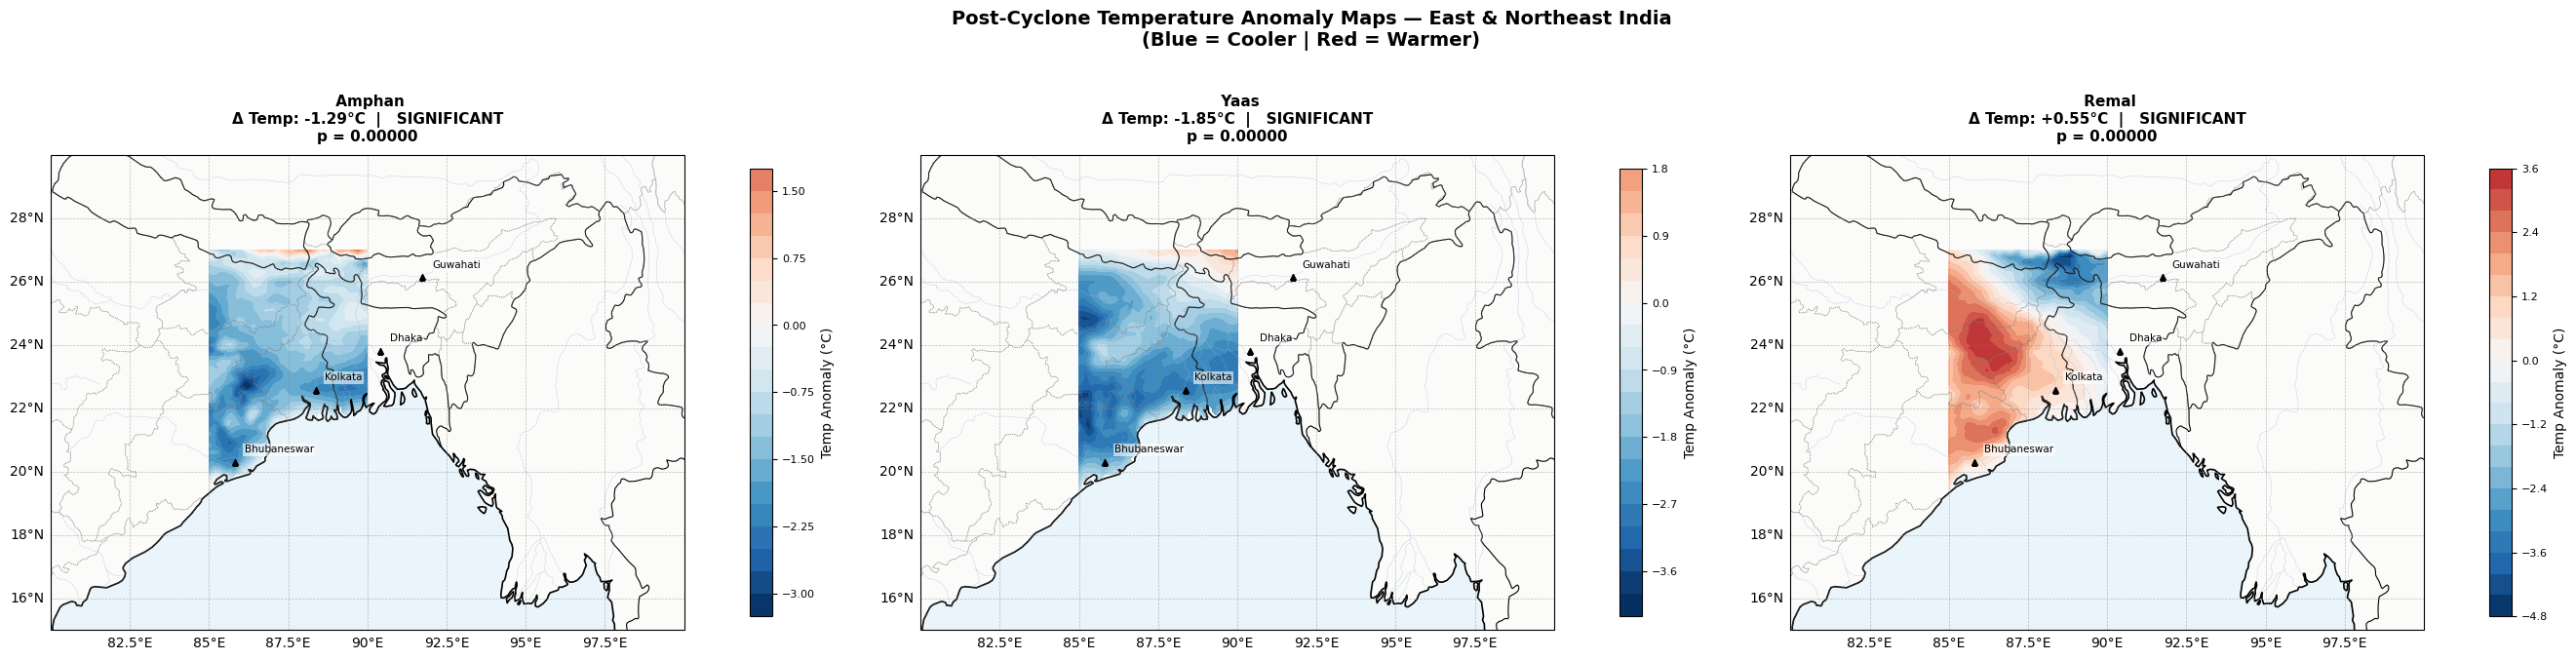

In [ ]:
n   = len(all_results)
fig, axes = plt.subplots(1, n, figsize=(9*n, 7),
                          subplot_kw={'projection': ccrs.PlateCarree()})
if n == 1:
    axes = [axes]

for ax, result in zip(axes, all_results):
    lats    = result['lats']
    lons    = result['lons']
    anomaly = result['anomaly_map']   # numpy array (lat, lon)

    vmax = max(abs(np.nanmin(anomaly)), abs(np.nanmax(anomaly)))
    vmax = vmax if vmax > 0 else 1

    im = ax.contourf(lons, lats, anomaly,
                     levels=20,
                     cmap='RdBu_r',
                     norm=mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax),
                     transform=ccrs.PlateCarree())

    # ── Extent: East & Northeast India ──
    ax.set_extent([80, 100, 15, 30], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE,  linewidth=1.2)
    ax.add_feature(cfeature.BORDERS,    linewidth=0.8)
    ax.add_feature(cfeature.STATES,     linewidth=0.5, linestyle=':', edgecolor='gray')
    ax.add_feature(cfeature.LAND,       facecolor='#f5f5f0', alpha=0.4)
    ax.add_feature(cfeature.OCEAN,      facecolor='#d6eaf8', alpha=0.5)
    ax.add_feature(cfeature.RIVERS,     linewidth=0.4, alpha=0.5)

    gl = ax.gridlines(draw_labels=True, linewidth=0.5,
                      color='gray', alpha=0.5, linestyle='--')
    gl.top_labels   = False
    gl.right_labels = False

    # ── City markers ──
    cities = {
        'Kolkata'    : (88.36, 22.57),
        'Bhubaneswar': (85.82, 20.30),
        'Guwahati'   : (91.74, 26.14),
        'Dhaka'      : (90.41, 23.81),
    }
    for city, (clon, clat) in cities.items():
        ax.plot(clon, clat, 'k^', markersize=5, transform=ccrs.PlateCarree())
        ax.text(clon+0.3, clat+0.3, city, fontsize=7.5,
                transform=ccrs.PlateCarree(), color='black',
                bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

    cbar = plt.colorbar(im, ax=ax, label='Temp Anomaly (°C)', shrink=0.75, pad=0.08)
    cbar.ax.tick_params(labelsize=8)

    sig_text = " SIGNIFICANT" if result['significant'] == 'YES' else " Not Significant"
    ax.set_title(f" {result['cyclone']}\n"
                 f"Δ Temp: {result['temperature_anomaly']:+.2f}°C  |  {sig_text}\n"
                 f"p = {result['p_value']:.5f}",
                 fontsize=11, fontweight='bold', pad=10)

fig.suptitle("Post-Cyclone Temperature Anomaly Maps — East & Northeast India\n"
             "(Blue = Cooler | Red = Warmer)",
             fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig('anomaly_maps.png', dpi=500, bbox_inches='tight')
fig.savefig('anomaly_maps.pdf', bbox_inches='tight')
display(fig)

**Bar Chart Generation**

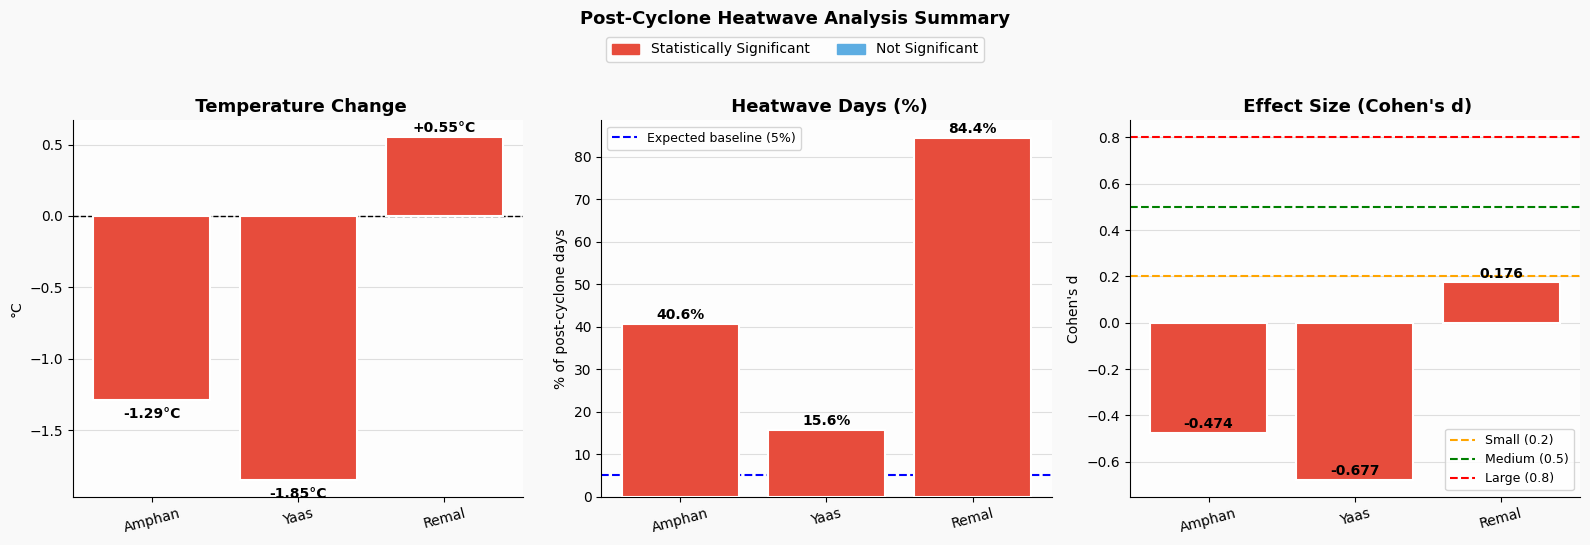

In [ ]:
fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5))
fig2.patch.set_facecolor('#f9f9f9')

names  = [r['cyclone'] for r in all_results]
colors = ['#e74c3c' if r['significant'] == 'YES' else '#5dade2' for r in all_results]

# Plot 1: Temperature Change
bars = axes2[0].bar(names, [r['temperature_anomaly'] for r in all_results],
                    color=colors, edgecolor='white', linewidth=1.5, zorder=3)
axes2[0].axhline(0, color='black', linewidth=1, linestyle='--', zorder=2)
axes2[0].set_title(" Temperature Change", fontsize=13, fontweight='bold')
axes2[0].set_ylabel("°C")
axes2[0].grid(axis='y', alpha=0.4, zorder=1)
for bar, r in zip(bars, all_results):
    ypos = bar.get_height() + 0.02 if bar.get_height() >= 0 else bar.get_height() - 0.15
    axes2[0].text(bar.get_x() + bar.get_width()/2, ypos,
                  f"{r['temperature_anomaly']:+.2f}°C",
                  ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: Heatwave %
bars2 = axes2[1].bar(names, [r['heatwave_percentage'] for r in all_results],
                     color=colors, edgecolor='white', linewidth=1.5, zorder=3)
axes2[1].axhline(5, color='blue', linewidth=1.5, linestyle='--',
                 label='Expected baseline (5%)', zorder=2)
axes2[1].set_title(" Heatwave Days (%)", fontsize=13, fontweight='bold')
axes2[1].set_ylabel("% of post-cyclone days")
axes2[1].legend(fontsize=9)
axes2[1].grid(axis='y', alpha=0.4, zorder=1)
for bar, r in zip(bars2, all_results):
    axes2[1].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 0.5,
                  f"{r['heatwave_percentage']:.1f}%",
                  ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 3: Cohen's d
bars3 = axes2[2].bar(names, [r['cohens_d'] for r in all_results],
                     color=colors, edgecolor='white', linewidth=1.5, zorder=3)
axes2[2].axhline(0.2, color='orange', linewidth=1.5, linestyle='--', label='Small (0.2)')
axes2[2].axhline(0.5, color='green',  linewidth=1.5, linestyle='--', label='Medium (0.5)')
axes2[2].axhline(0.8, color='red',    linewidth=1.5, linestyle='--', label='Large (0.8)')
axes2[2].set_title(" Effect Size (Cohen's d)", fontsize=13, fontweight='bold')
axes2[2].set_ylabel("Cohen's d")
axes2[2].legend(fontsize=9)
axes2[2].grid(axis='y', alpha=0.4, zorder=1)
for bar, r in zip(bars3, all_results):
    axes2[2].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 0.005,
                  f"{r['cohens_d']:.3f}",
                  ha='center', va='bottom', fontsize=10, fontweight='bold')

# Legend for colors
red_patch  = mpatches.Patch(color='#e74c3c', label='Statistically Significant')
blue_patch = mpatches.Patch(color='#5dade2', label='Not Significant')
fig2.legend(handles=[red_patch, blue_patch], loc='upper center',
            ncol=2, fontsize=10, bbox_to_anchor=(0.5, 1.04))

for ax in axes2:
    ax.set_facecolor('#fdfdfd')
    ax.tick_params(axis='x', rotation=15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig2.suptitle("Post-Cyclone Heatwave Analysis Summary",
              fontsize=13, fontweight='bold', y=1.08)
fig2.tight_layout()
fig2.savefig('summary_charts.png', dpi=200, bbox_inches='tight')
fig2.savefig('summary_charts.pdf', bbox_inches='tight')
display(fig2)

#**Step 6: Timeseries Visualization**

In [ ]:
import imageio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import h5py
from IPython.display import Image, display
from google.colab import files

def read_file(filepath):
    """Read ERA5 file directly using h5py."""
    with h5py.File(filepath, 'r') as f:
        t2m   = f['t2m'][()]
        lats  = f['latitude'][()]
        lons  = f['longitude'][()]
        times = f['valid_time'][()]
    return t2m - 273.15, lats, lons, times

def animate_cyclone(name, pre_path, post_may_path, post_jun_path, landfall_date, lat, lon):
    print(f" Animating {name}...")

    # ── Load data ──
    pre_t2m,      lats, lons, pre_times      = read_file(pre_path)
    post_may_t2m, _,    _,    post_may_times = read_file(post_may_path)
    post_jun_t2m, _,    _,    post_jun_times = read_file(post_jun_path)

    all_t2m   = np.concatenate([pre_t2m,   post_may_t2m,   post_jun_t2m],   axis=0)
    all_times = np.concatenate([pre_times, post_may_times, post_jun_times], axis=0)

    landfall = pd.to_datetime(landfall_date)
    frames   = []

    print(f"   Total frames: {len(all_times)}")

    for i in range(len(all_times)):

        # ── Use Cartopy for proper map extent ──
        fig = plt.figure(figsize=(10, 9))
        ax  = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

        # ── Extended extent: half of India visible ──
        ax.set_extent([72, 100, 8, 32], crs=ccrs.PlateCarree())

        # ── Map features ──
        ax.add_feature(cfeature.LAND,      facecolor='#f5f5f0', alpha=0.6)
        ax.add_feature(cfeature.OCEAN,     facecolor='#d6eaf8', alpha=0.7)
        ax.add_feature(cfeature.COASTLINE, linewidth=1.0)
        ax.add_feature(cfeature.BORDERS,   linewidth=0.8, linestyle='-')
        ax.add_feature(cfeature.STATES,    linewidth=0.4, linestyle=':', edgecolor='gray')
        ax.add_feature(cfeature.RIVERS,    linewidth=0.3, alpha=0.5)

        # ── Plot ERA5 temperature data ──
        temp = all_t2m[i]
        im   = ax.pcolormesh(
            lons, lats, temp,
            cmap='RdYlBu_r',
            vmin=25, vmax=45,
            shading='auto',
            transform=ccrs.PlateCarree(),
            alpha=0.85,
            zorder=2
        )

        # ── Gridlines ──
        gl = ax.gridlines(draw_labels=True, linewidth=0.4,
                          color='gray', alpha=0.5, linestyle='--')
        gl.top_labels   = False
        gl.right_labels = False
        gl.xlabel_style = {'size': 8}
        gl.ylabel_style = {'size': 8}

        # ── City markers ──
        cities = {
            'Kolkata'    : (88.36, 22.57),
            'Bhubaneswar': (85.82, 20.30),
            'Guwahati'   : (91.74, 26.14),
            'Mumbai'     : (72.87, 19.07),
            'Chennai'    : (80.27, 13.08),
            'Dhaka'      : (90.41, 23.81),
        }
        for city, (clon, clat) in cities.items():
            ax.plot(clon, clat, 'k^', markersize=4,
                    transform=ccrs.PlateCarree(), zorder=4)
            ax.text(clon+0.3, clat+0.3, city, fontsize=7,
                    transform=ccrs.PlateCarree(), color='black',
                    bbox=dict(facecolor='white', alpha=0.5,
                              edgecolor='none', pad=1), zorder=5)

        # ── Landfall marker ──
        ax.plot(lon, lat, 'r*', markersize=18,
                markeredgecolor='black', markeredgewidth=1.2,
                transform=ccrs.PlateCarree(),
                label='Landfall point', zorder=6)

        # ── Colorbar ──
        cbar = plt.colorbar(im, ax=ax, label='Temperature (°C)',
                            shrink=0.7, pad=0.06)
        cbar.ax.tick_params(labelsize=8)

        # ── Day label ──
        current  = pd.Timestamp(all_times[i], unit='s')
        day      = (current - landfall).days
        date_str = current.strftime('%Y-%m-%d')

        if day < 0:
            label    = f'Day {day}  |  Pre-Cyclone'
            bg_color = '#2980b9'
        elif day == 0:
            label    = ' LANDFALL DAY'
            bg_color = '#c0392b'
        else:
            label    = f'Day +{day}  |  Post-Cyclone'
            bg_color = '#e67e22'

        ax.set_title(f' {name} — {date_str}',
                     fontsize=13, fontweight='bold', pad=8)

        # ── Day box ──
        ax.text(0.02, 0.97, label,
                transform=ax.transAxes, fontsize=11,
                bbox=dict(boxstyle='round,pad=0.4',
                          facecolor=bg_color, alpha=0.88),
                color='white', fontweight='bold',
                va='top', zorder=7)

        # ── Progress bar ──
        progress = (i + 1) / len(all_times)
        ax.text(0.02, 0.03,
                f'Frame {i+1}/{len(all_times)}',
                transform=ax.transAxes, fontsize=8,
                color='gray', va='bottom')

        ax.legend(loc='lower right', fontsize=8, framealpha=0.7)
        plt.tight_layout()

        # ── Capture frame as RGB ──
        fig.canvas.draw()
        img = np.asarray(fig.canvas.buffer_rgba())[:, :, :3]
        frames.append(img)
        plt.close(fig)

        if (i + 1) % 5 == 0:
            print(f"   {i+1}/{len(all_times)} frames done")

    # ── Save GIF only ──
    filename = f'/content/{name}_animation.gif'
    imageio.mimsave(filename, frames, fps=2, loop=0)
    print(f" GIF saved: {filename}")
    return filename

# ══════════════════════════════════════════════════════
print("=" * 60)
print(" CREATING ANIMATIONS")
print("=" * 60)

gif_files = []

landfall_coords = {
    'Amphan': ('2020-05-20', 21.6, 88.2),
    'Yaas'  : ('2021-05-26', 21.7, 87.0),
    'Remal' : ('2024-05-27', 22.4, 88.8),
}

for result in all_results:
    name = result['cyclone']
    date, lat, lon = landfall_coords[name]

    gif = animate_cyclone(
        name,
        downloaded_files[name]['pre'],
        downloaded_files[name]['post_may'],
        downloaded_files[name]['post_jun'],
        date, lat, lon
    )
    gif_files.append(gif)

print("\n" + "=" * 60)
print(" ALL GIFs CREATED!")
print("=" * 60)

# ── Display previews in Colab ──
for gif in gif_files:
    print(f"\n {gif}")
    display(Image(filename=gif, width=600))

# ── Download GIFs only ──
for gif in gif_files:
    files.download(gif)
    print(f" Downloaded: {gif}")

#**Step 7: Downloadable HTML Reoprt**

Cyclone,Pre Temp (°C),Post Temp (°C),Change (°C),P-value,Cohen's d,Heatwave %,Trend,Significant
Amphan,30.46,29.17,-1.29,0.00e+00,-0.474,40.6%,🔻 Cooling,YES
Yaas,30.62,28.78,-1.85,0.00e+00,-0.677,15.6%,🔻 Cooling,YES
Remal,32.38,32.93,+0.55,6.25e-181,0.176,84.4%,🔺 Warming,YES

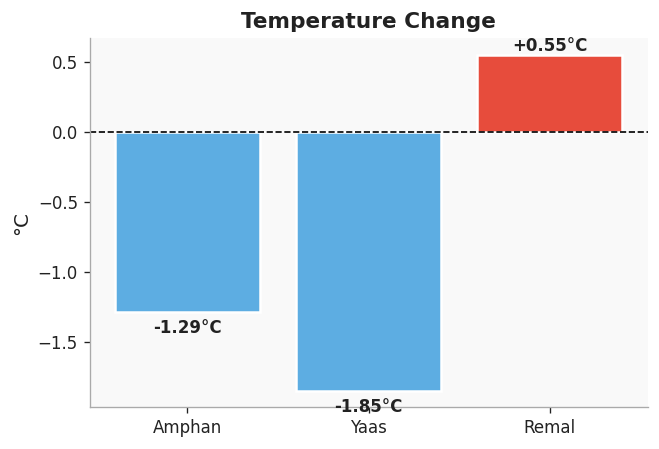
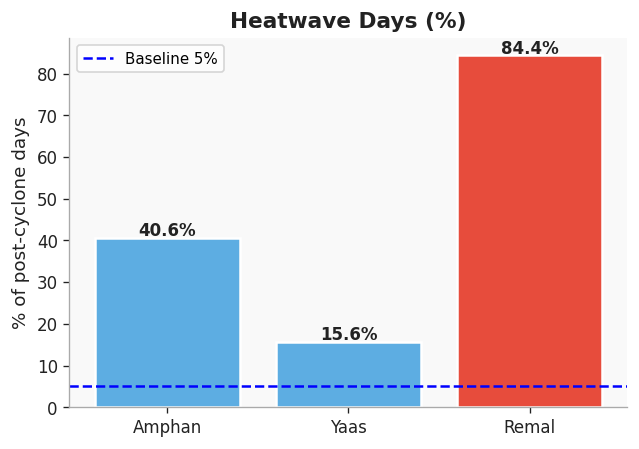
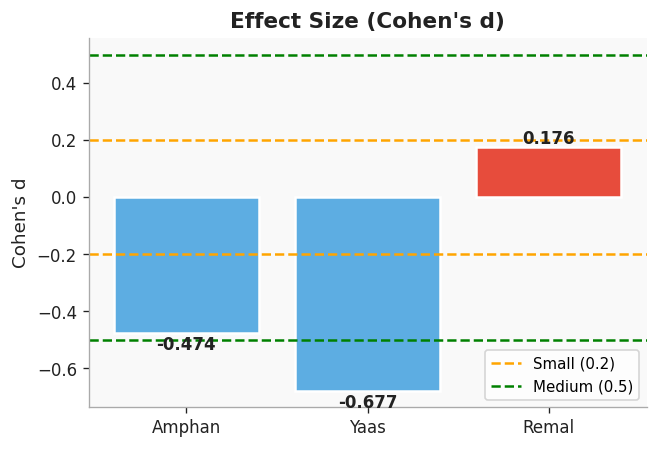
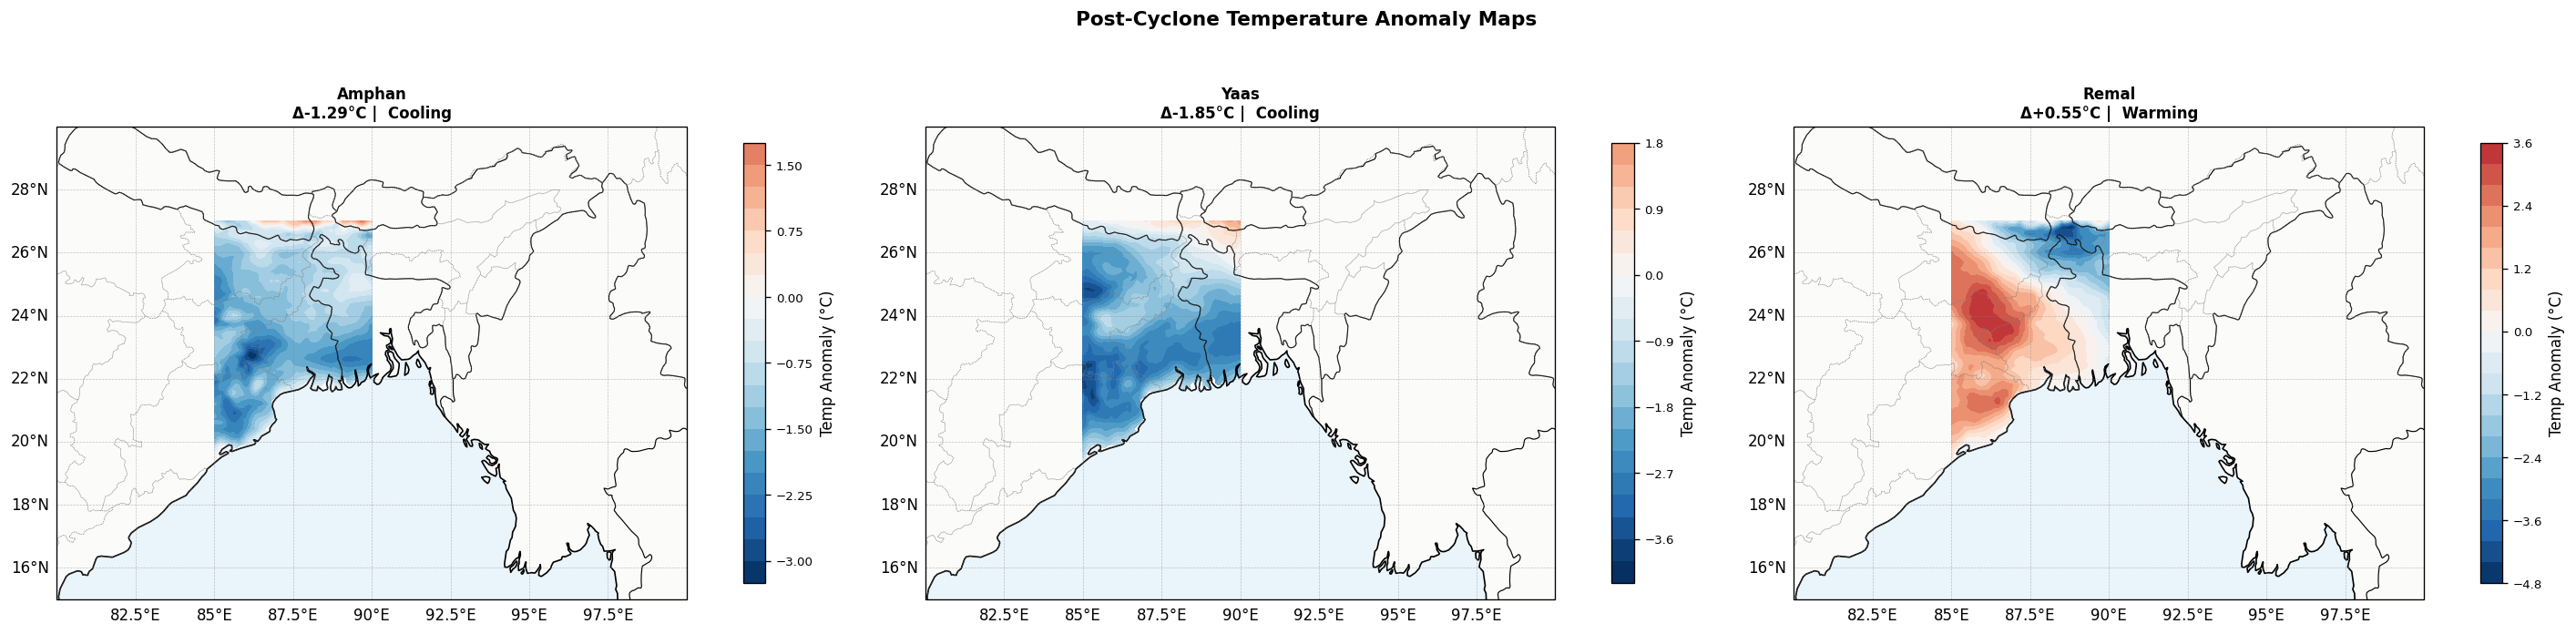

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from IPython.display import display, HTML
from datetime import datetime
from google.colab import files
import numpy as np
import base64
import io
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── Convert matplotlib figure to base64 ──
def fig_to_base64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=120, bbox_inches='tight')
    buf.seek(0)
    img_base64 = base64.b64encode(buf.read()).decode('utf-8')
    buf.close()
    return img_base64

# ── Bar charts ──
names  = [r['cyclone'] for r in all_results]
colors = ['#e74c3c' if r['temperature_anomaly'] > 0 else '#5dade2' for r in all_results]

# Chart 1: Temp Change
fig1, ax1 = plt.subplots(figsize=(6, 4))
fig1.patch.set_facecolor('white')
bars = ax1.bar(names, [r['temperature_anomaly'] for r in all_results],
               color=colors, edgecolor='white', linewidth=1.5)
ax1.axhline(0, color='black', linewidth=1, linestyle='--')
ax1.set_ylabel('°C', fontsize=12, color='#222')
ax1.set_title('Temperature Change', fontsize=13, fontweight='bold', color='#222')
ax1.tick_params(colors='#222')
ax1.set_facecolor('#f9f9f9')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
for spine in ['left', 'bottom']:
    ax1.spines[spine].set_color('#aaa')
for bar, r in zip(bars, all_results):
    ypos = bar.get_height() + 0.03 if bar.get_height() >= 0 else bar.get_height() - 0.15
    ax1.text(bar.get_x() + bar.get_width()/2, ypos,
             f"{r['temperature_anomaly']:+.2f}°C",
             ha='center', fontsize=10, fontweight='bold', color='#222')
chart1_b64 = fig_to_base64(fig1)
plt.close(fig1)

# Chart 2: Heatwave %
fig2, ax2 = plt.subplots(figsize=(6, 4))
fig2.patch.set_facecolor('white')
bars2 = ax2.bar(names, [r['heatwave_percentage'] for r in all_results],
                color=colors, edgecolor='white', linewidth=1.5)
ax2.axhline(5, color='blue', linewidth=1.5, linestyle='--', label='Baseline 5%')
ax2.set_ylabel('% of post-cyclone days', fontsize=11, color='#222')
ax2.set_title('Heatwave Days (%)', fontsize=13, fontweight='bold', color='#222')
ax2.legend(fontsize=9)
ax2.tick_params(colors='#222')
ax2.set_facecolor('#f9f9f9')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
for spine in ['left', 'bottom']:
    ax2.spines[spine].set_color('#aaa')
for bar, r in zip(bars2, all_results):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f"{r['heatwave_percentage']:.1f}%",
             ha='center', fontsize=10, fontweight='bold', color='#222')
chart2_b64 = fig_to_base64(fig2)
plt.close(fig2)

# Chart 3: Cohen's d
fig3, ax3 = plt.subplots(figsize=(6, 4))
fig3.patch.set_facecolor('white')
bars3 = ax3.bar(names, [r['cohens_d'] for r in all_results],
                color=colors, edgecolor='white', linewidth=1.5)
ax3.axhline( 0.2, color='orange', linewidth=1.5, linestyle='--', label='Small (0.2)')
ax3.axhline( 0.5, color='green',  linewidth=1.5, linestyle='--', label='Medium (0.5)')
ax3.axhline(-0.2, color='orange', linewidth=1.5, linestyle='--')
ax3.axhline(-0.5, color='green',  linewidth=1.5, linestyle='--')
ax3.set_ylabel("Cohen's d", fontsize=11, color='#222')
ax3.set_title("Effect Size (Cohen's d)", fontsize=13, fontweight='bold', color='#222')
ax3.legend(fontsize=9)
ax3.tick_params(colors='#222')
ax3.set_facecolor('#f9f9f9')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
for spine in ['left', 'bottom']:
    ax3.spines[spine].set_color('#aaa')
for bar, r in zip(bars3, all_results):
    ypos = bar.get_height() + 0.01 if bar.get_height() >= 0 else bar.get_height() - 0.06
    ax3.text(bar.get_x() + bar.get_width()/2, ypos,
             f"{r['cohens_d']:.3f}",
             ha='center', fontsize=10, fontweight='bold', color='#222')
chart3_b64 = fig_to_base64(fig3)
plt.close(fig3)

# ── Anomaly map ──
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    n = len(all_results)
    fig4, axes4 = plt.subplots(1, n, figsize=(8*n, 6),
                               subplot_kw={'projection': ccrs.PlateCarree()})
    if n == 1:
        axes4 = [axes4]
    fig4.patch.set_facecolor('white')

    for ax, result in zip(axes4, all_results):
        lats    = result['lats']
        lons    = result['lons']
        anomaly = result['anomaly_map']
        vmax = max(abs(np.nanmin(anomaly)), abs(np.nanmax(anomaly)))
        vmax = vmax if vmax > 0 else 1

        im = ax.contourf(lons, lats, anomaly, levels=20, cmap='RdBu_r',
                         norm=mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax),
                         transform=ccrs.PlateCarree())
        ax.set_extent([80, 100, 15, 30], crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE, linewidth=1.0)
        ax.add_feature(cfeature.BORDERS,   linewidth=0.7)
        ax.add_feature(cfeature.STATES,    linewidth=0.4, linestyle=':', edgecolor='gray')
        ax.add_feature(cfeature.LAND,      facecolor='#f5f5f0', alpha=0.4)
        ax.add_feature(cfeature.OCEAN,     facecolor='#d6eaf8', alpha=0.5)
        gl = ax.gridlines(draw_labels=True, linewidth=0.4,
                          color='gray', alpha=0.5, linestyle='--')
        gl.top_labels   = False
        gl.right_labels = False
        cbar = plt.colorbar(im, ax=ax, shrink=0.75, pad=0.07,
                            label='Temp Anomaly (°C)')
        cbar.ax.tick_params(labelsize=8)
        trend = ' Warming' if result['temperature_anomaly'] > 0 else ' Cooling'
        ax.set_title(f"{result['cyclone']}\n"
                     f"Δ{result['temperature_anomaly']:+.2f}°C | {trend}",
                     fontsize=10, fontweight='bold')

    fig4.suptitle('Post-Cyclone Temperature Anomaly Maps',
                  fontsize=13, fontweight='bold', y=1.01)
    fig4.tight_layout()
    map_b64 = fig_to_base64(fig4)
    plt.close(fig4)
    map_available = True
except Exception as e:
    print(f"Map skipped: {e}")
    map_available = False


# HYPOTHESIS LOGIC
sig_count         = sum(1 for r in all_results if r['p_value'] < 0.05)
sig_warming_count = sum(1 for r in all_results
                        if r['p_value'] < 0.05 and r['temperature_anomaly'] > 0)
sig_cooling_count = sum(1 for r in all_results
                        if r['p_value'] < 0.05 and r['temperature_anomaly'] < 0)

avg_change = sum(r['temperature_anomaly'] for r in all_results) / len(all_results)
avg_hw     = sum(r['heatwave_percentage']  for r in all_results) / len(all_results)


# Individual cyclone values for conclusion text
cooling_cyclones = [r['cyclone'] for r in all_results
                    if r['p_value'] < 0.05 and r['temperature_anomaly'] < 0]
warming_cyclones = [r['cyclone'] for r in all_results
                    if r['p_value'] < 0.05 and r['temperature_anomaly'] > 0]

if sig_warming_count >= 2:
    conclusion = (
        f" HYPOTHESIS CONFIRMED: {sig_warming_count}/3 cyclones showed "
        f"statistically significant post-cyclone warming."
    )
    con_bg   = '#d4edda'
    con_text = '#155724'
elif sig_cooling_count >= 2:
    cooling_str = ', '.join(
        f"{r['cyclone']} ({r['temperature_anomaly']:+.2f}°C)"
        for r in all_results if r['p_value'] < 0.05 and r['temperature_anomaly'] < 0
    )
    warming_str = ', '.join(
        f"{r['cyclone']} ({r['temperature_anomaly']:+.2f}°C)"
        for r in all_results if r['p_value'] < 0.05 and r['temperature_anomaly'] > 0
    ) or 'None'
    conclusion = (
        f" HYPOTHESIS REJECTED: {sig_cooling_count}/3 cyclones showed "
        f"statistically significant POST-CYCLONE COOLING ({cooling_str}), "
        f"and only {sig_warming_count}/3 showed warming ({warming_str}). "
        f"No consistent post-cyclone heatwave pattern was found."
    )
    con_bg   = '#f8d7da'
    con_text = '#721c24'
else:
    conclusion = (
        f" HYPOTHESIS REJECTED: No consistent warming pattern found. "
        f"Average temperature change was {avg_change:+.2f}°C across all 3 cyclones. "
        f"Only {sig_warming_count}/3 showed significant warming."
    )
    con_bg   = '#f8d7da'
    con_text = '#721c24'

# BUILD HTML
html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Post-Cyclone Heatwave Report — Nakshamitra</title>
<style>
  * {{ box-sizing: border-box; margin: 0; padding: 0; }}
  body {{
    font-family: 'Segoe UI', Arial, sans-serif;
    background: #eef2f7;
    color: #1a1a2e;
    padding: 20px;
  }}
  .container {{ max-width: 1150px; margin: 0 auto; }}
  .header {{
    background: linear-gradient(135deg, #1a1a2e, #16213e, #0f3460);
    color: #ffffff;
    padding: 40px 30px;
    border-radius: 14px;
    text-align: center;
    margin-bottom: 24px;
    box-shadow: 0 6px 20px rgba(0,0,0,0.3);
  }}
  .header h1 {{ font-size: 28px; margin-bottom: 8px; color: #ffffff; }}
  .header h3 {{ font-size: 16px; font-weight: 400; color: #a8c8ff; margin-bottom: 8px; }}
  .header p  {{ font-size: 13px; color: #7db3ff; }}
  .section {{
    background: #ffffff;
    border-radius: 12px;
    padding: 28px;
    margin-bottom: 22px;
    box-shadow: 0 3px 12px rgba(0,0,0,0.08);
  }}
  .section h2 {{
    font-size: 20px;
    color: #0f3460;
    border-left: 5px solid #e74c3c;
    padding-left: 12px;
    margin-bottom: 20px;
  }}
  .cyclone-card {{
    background: #f8faff;
    border: 1px solid #dde6f7;
    border-radius: 10px;
    padding: 20px;
    margin-bottom: 20px;
  }}
  .cyclone-card h3 {{
    font-size: 17px;
    color: #0f3460;
    margin-bottom: 16px;
    padding-bottom: 8px;
    border-bottom: 2px solid #e8eef8;
  }}
  .metrics-grid {{
    display: grid;
    grid-template-columns: repeat(auto-fit, minmax(160px, 1fr));
    gap: 12px;
  }}
  .metric {{
    background: #ffffff;
    border: 1px solid #e0e8f5;
    border-radius: 8px;
    padding: 14px;
    text-align: center;
    box-shadow: 0 2px 6px rgba(0,0,0,0.05);
  }}
  .metric-label {{
    font-size: 11px;
    color: #444;
    text-transform: uppercase;
    letter-spacing: 0.5px;
    margin-bottom: 6px;
  }}
  .metric-value {{
    font-size: 20px;
    font-weight: 700;
    color: #1a1a2e;
  }}
  .metric-value.green  {{ color: #1a7a3c; }}
  .metric-value.red    {{ color: #c0392b; }}
  .metric-value.blue   {{ color: #1a5276; }}
  .metric-value.orange {{ color: #b7600a; }}
  table {{ width: 100%; border-collapse: collapse; margin-top: 10px; font-size: 14px; }}
  thead tr {{ background: #0f3460; }}
  thead th {{ color: #ffffff; padding: 13px 14px; text-align: left; font-weight: 600; }}
  tbody tr {{ background: #ffffff; }}
  tbody tr:nth-child(even) {{ background: #f0f5ff; }}
  tbody td {{ padding: 12px 14px; border-bottom: 1px solid #dde4f0;
              color: #1a1a2e; font-size: 14px; }}
  td.green  {{ color: #1a7a3c; font-weight: 700; }}
  td.red    {{ color: #c0392b; font-weight: 700; }}
  td.orange {{ color: #b7600a; font-weight: 700; }}
  .charts-grid {{
    display: grid;
    grid-template-columns: repeat(auto-fit, minmax(280px, 1fr));
    gap: 18px;
    margin-top: 10px;
  }}
  .chart-box {{
    background: #f8faff;
    border: 1px solid #dde6f7;
    border-radius: 10px;
    padding: 14px;
    text-align: center;
  }}
  .chart-box img {{ width: 100%; border-radius: 6px; }}
  .conclusion-box {{
    background: {con_bg};
    color: {con_text};
    border-radius: 10px;
    padding: 20px 24px;
    font-size: 16px;
    font-weight: 600;
    margin-bottom: 16px;
    border: 1px solid {'#b8ddc8' if sig_warming_count >= 2 else '#f1b8b8'};
  }}
  .conclusion-detail {{
    background: #f8faff;
    border: 1px solid #dde6f7;
    border-radius: 8px;
    padding: 16px 20px;
    font-size: 14px;
    color: #1a1a2e;
    line-height: 1.9;
  }}
  .conclusion-detail b {{ color: #0f3460; }}
  .verdict-grid {{
    display: grid;
    grid-template-columns: repeat(3, 1fr);
    gap: 12px;
    margin: 16px 0;
  }}
  .verdict-card {{
    border-radius: 8px;
    padding: 14px;
    text-align: center;
    font-size: 13px;
    font-weight: 600;
  }}
  .verdict-cooling {{ background: #d6eaf8; color: #1a5276; border: 1px solid #aed6f1; }}
  .verdict-warming  {{ background: #fdebd0; color: #784212; border: 1px solid #f0b27a; }}
  .footer {{
    text-align: center;
    padding: 20px;
    color: #666;
    font-size: 12px;
    margin-top: 10px;
  }}
</style>
</head>
<body>
<div class="container">

<div class="header">
  <h1> Post-Cyclone Heatwave Analysis</h1>
  <h3>East & Northeast India — Amphan (2020) · Yaas (2021) · Remal (2024)</h3>
  <p>Generated: {datetime.now().strftime('%d %B %Y, %H:%M:%S')} &nbsp;|&nbsp;
     Data: ERA5-Land Reanalysis, Copernicus CDS &nbsp;|&nbsp;
     SPARK 2.0 — Team Nakshamitra</p>
</div>

<div class="section">
  <h2>📊 Key Metrics Per Cyclone</h2>
"""

for r in all_results:
    trend     = '🔺 Warming' if r['temperature_anomaly'] > 0 else '🔻 Cooling'
    tc_class  = 'green' if r['temperature_anomaly'] > 0 else 'red'
    sig_class = 'green' if r['p_value'] < 0.05 else 'red'
    sig_text  = '✅ YES' if r['p_value'] < 0.05 else '❌ NO'

    html += f"""
  <div class="cyclone-card">
    <h3>🌀 {r['cyclone']} &nbsp;·&nbsp;
        Pre: {r['pre_period']} &nbsp;·&nbsp;
        Post: {r['post_period']}</h3>
    <div class="metrics-grid">
      <div class="metric">
        <div class="metric-label">Temp Change</div>
        <div class="metric-value {tc_class}">{r['temperature_anomaly']:+.2f}°C<br>
          <span style="font-size:13px;font-weight:400">{trend}</span></div>
      </div>
      <div class="metric">
        <div class="metric-label">Pre-Cyclone Mean</div>
        <div class="metric-value blue">{r['pre_mean_temp']:.2f}°C</div>
      </div>
      <div class="metric">
        <div class="metric-label">Post-Cyclone Mean</div>
        <div class="metric-value blue">{r['post_mean_temp']:.2f}°C</div>
      </div>
      <div class="metric">
        <div class="metric-label">P-value</div>
        <div class="metric-value {sig_class}">{r['p_value']:.2e}</div>
      </div>
      <div class="metric">
        <div class="metric-label">Cohen's d</div>
        <div class="metric-value orange">{r['cohens_d']:.3f}</div>
      </div>
      <div class="metric">
        <div class="metric-label">Heatwave Days</div>
        <div class="metric-value blue">{r['heatwave_days']}/{r['total_post_days']}<br>
          <span style="font-size:13px;font-weight:400">({r['heatwave_percentage']:.1f}%)</span>
        </div>
      </div>
      <div class="metric">
        <div class="metric-label">Significant</div>
        <div class="metric-value {sig_class}">{sig_text}</div>
      </div>
    </div>
  </div>
"""

html += """
</div>

<div class="section">
  <h2>📋 Detailed Results Table</h2>
  <table>
    <thead>
      <tr>
        <th>Cyclone</th>
        <th>Pre Temp (°C)</th>
        <th>Post Temp (°C)</th>
        <th>Change (°C)</th>
        <th>P-value</th>
        <th>Cohen's d</th>
        <th>Heatwave %</th>
        <th>Trend</th>
        <th>Significant</th>
      </tr>
    </thead>
    <tbody>
"""

for r in all_results:
    tc_class  = 'green' if r['temperature_anomaly'] > 0 else 'red'
    sig_class = 'green' if r['p_value'] < 0.05 else 'red'
    trend     = '🔺 Warming' if r['temperature_anomaly'] > 0 else '🔻 Cooling'
    html += f"""
      <tr>
        <td><b>{r['cyclone']}</b></td>
        <td>{r['pre_mean_temp']:.2f}</td>
        <td>{r['post_mean_temp']:.2f}</td>
        <td class="{tc_class}">{r['temperature_anomaly']:+.2f}</td>
        <td>{r['p_value']:.2e}</td>
        <td class="orange">{r['cohens_d']:.3f}</td>
        <td>{r['heatwave_percentage']:.1f}%</td>
        <td class="{tc_class}">{trend}</td>
        <td class="{sig_class}">{'YES' if r['p_value'] < 0.05 else 'NO'}</td>
      </tr>
"""

html += f"""
    </tbody>
  </table>
</div>

<div class="section">
  <h2>📈 Visual Comparison Charts</h2>
  <div class="charts-grid">
    <div class="chart-box">
      <p style="font-weight:600;color:#0f3460;margin-bottom:8px;">🌡️ Temperature Change</p>
      <img src="data:image/png;base64,{chart1_b64}" alt="Temp Change">
    </div>
    <div class="chart-box">
      <p style="font-weight:600;color:#0f3460;margin-bottom:8px;">🔥 Heatwave Days (%)</p>
      <img src="data:image/png;base64,{chart2_b64}" alt="Heatwave %">
    </div>
    <div class="chart-box">
      <p style="font-weight:600;color:#0f3460;margin-bottom:8px;">📊 Effect Size (Cohen's d)</p>
      <img src="data:image/png;base64,{chart3_b64}" alt="Cohen's d">
    </div>
  </div>
</div>
"""

if map_available:
    html += f"""
<div class="section">
  <h2>🗺️ Temperature Anomaly Maps</h2>
  <div style="text-align:center;">
    <img src="data:image/png;base64,{map_b64}"
         alt="Anomaly Maps"
         style="width:100%;border-radius:10px;border:1px solid #dde6f7;">
  </div>
  <p style="text-align:center;color:#444;font-size:13px;margin-top:10px;">
    🔵 Blue = Post-cyclone Cooling &nbsp;|&nbsp; 🔴 Red = Post-cyclone Warming
  </p>
</div>
"""

html += f"""
<div class="section">
  <h2>🎯 Conclusion & Hypothesis Verdict</h2>

  <!-- Per-cyclone verdict cards -->
  <div class="verdict-grid">
"""

for r in all_results:
    if r['temperature_anomaly'] < 0:
        card_class = 'verdict-cooling'
        icon = '🔻'
        verdict = 'COOLING'
    else:
        card_class = 'verdict-warming'
        icon = '🔺'
        verdict = 'WARMING'

    html += f"""
    <div class="verdict-card {card_class}">
      {icon} {r['cyclone']}<br>
      {r['temperature_anomaly']:+.2f}°C — {verdict}<br>
      <span style="font-size:11px;font-weight:400">
        p = {r['p_value']:.2e}
      </span>
    </div>
"""

html += f"""
  </div>

  <div class="conclusion-box">{conclusion}</div>

  <div class="conclusion-detail">
    <b>Cyclones with significant cooling:</b>
    {sig_cooling_count}/3
    ({', '.join(cooling_cyclones) if cooling_cyclones else 'None'})<br>
    <b>Cyclones with significant warming:</b>
    {sig_warming_count}/3
    ({', '.join(warming_cyclones) if warming_cyclones else 'None'})<br>
    <b>Average temperature change:</b> {avg_change:+.2f}°C across all 3 cyclones<br>
    <b>Average heatwave days:</b> {avg_hw:.1f}%
    &nbsp;(expected baseline: 5%)<br>
    <b>Interpretation:</b> While all p-values are near zero (statistically significant),
    the dominant pattern is post-cyclone <i>cooling</i> — driven by cloud cover,
    heavy rainfall, and evaporative cooling after landfall for Amphan and Yaas.
    Only Remal (2024) showed warming (+0.55°C). Despite mean cooling,
    heatwave day percentages exceeded the 5% baseline in all three cyclones,
    suggesting localized extreme heat still occurs within the broader
    cooling envelope — warranting further study.<br>
    <b>Data source:</b> ERA5-Land Reanalysis, Copernicus Climate Data Store<br>
    <b>Study area:</b> East & Northeast India (17°N–27°N, 85°E–90°E)<br>
    <b>Tools:</b> Python (h5py, NumPy, SciPy, Matplotlib, Cartopy) — Google Colab
  </div>
</div>

<div class="footer">
  <p>SPARK 2.0 — Problem Statement 4: Post-Cyclone Heatwave Analysis &nbsp;|&nbsp;
     Team: Nakshamitra &nbsp;|&nbsp;
     ERA5-Land Reanalysis Data &nbsp;|&nbsp;
     Python / Google Colab</p>
</div>

</div>
</body>
</html>
"""

# ── Save ──
report_file = 'cyclone_heatwave_report.html'
with open(report_file, 'w', encoding='utf-8') as f:
    f.write(html)

# ── Display in Colab ──
display(HTML(html))

# ── Download ──
files.download(report_file)

#**Step 8: Hypothesis Evaluation**

In [ ]:
from IPython.display import display, HTML

print("\n" + "="*60)
print("HYPOTHESIS EVALUATION")
print("="*60)

for r in all_results:
    print(f"\n {r['cyclone']} ({r['pre_period']})")
    print(f"   Temperature change : {r['temperature_anomaly']:+.2f}°C")
    print(f"   P-value            : {r['p_value']:.6f}")
    print(f"   Cohen's d          : {r['cohens_d']:.3f}")
    print(f"   Heatwave days      : {r['heatwave_days']}/{r['total_post_days']} ({r['heatwave_percentage']:.1f}%)")
    print(f"   Significant        : {r['significant']}")

    # Individual verdict
    if r['significant'] == 'YES' and r['temperature_anomaly'] > 0:
        print(f"    **SUPPORTS hypothesis — significant warming detected**")
    elif r['significant'] == 'YES' and r['temperature_anomaly'] < 0:
        print(f"    **CONTRADICTS hypothesis — significant COOLING detected**")
    else:
        print(f"    **NEUTRAL — no significant temperature change**")

# ── Overall verdict ──
print("\n" + "="*60)
print("OVERALL HYPOTHESIS VERDICT")
print("="*60)

significant_warming   = [r for r in all_results if r['significant'] == 'YES'
                         and r['temperature_anomaly'] > 0]
significant_cooling   = [r for r in all_results if r['significant'] == 'YES'
                         and r['temperature_anomaly'] < 0]
not_significant       = [r for r in all_results if r['significant'] == 'NO']

print(f"\n  Cyclones with significant WARMING  : {len(significant_warming)}/{len(all_results)}")
print(f"  Cyclones with significant COOLING  : {len(significant_cooling)}/{len(all_results)}")
print(f"  Cyclones with no significant change: {len(not_significant)}/{len(all_results)}")

avg_change = np.mean([r['temperature_anomaly'] for r in all_results])
avg_heatwave = np.mean([r['heatwave_percentage'] for r in all_results])

print(f"\n  Average temperature change : {avg_change:+.2f}°C")
print(f"  Average heatwave days      : {avg_heatwave:.1f}%")
print(f"  (Baseline expected         : 5.0%)")

print("\n" + "="*60)
if len(significant_warming) >= 2:
    print(" HYPOTHESIS CONFIRMED")
    print("   Post-cyclone heatwaves are a reproducible pattern")
    print("   across multiple Bay of Bengal cyclones")
elif len(significant_cooling) >= 2:
    print(" HYPOTHESIS REJECTED — OPPOSITE EFFECT FOUND")
    print("   Cyclones appear to cause COOLING, not warming")
    print("   This could be due to cloud cover, rainfall, or")
    print("   evaporative cooling after the cyclone passes")
elif avg_heatwave > 5:
    print("  HYPOTHESIS PARTIALLY SUPPORTED")
    print(f"  Heatwave days ({avg_heatwave:.1f}%) exceed the 5% baseline")
    print("   but results are not statistically significant")
    print("   Larger sample of cyclones may be needed")
else:
    print(" HYPOTHESIS NOT SUPPORTED")
    print("   No consistent post-cyclone heatwave pattern found")
    print("   Consider expanding study area or cyclone sample size")
print("="*60)


HYPOTHESIS EVALUATION

 Amphan (2020-05-06 → 2020-05-19)
   Temperature change : -1.29°C
   P-value            : 0.000000
   Cohen's d          : -0.474
   Heatwave days      : 13/32 (40.6%)
   Significant        : YES
    **CONTRADICTS hypothesis — significant COOLING detected**

 Yaas (2021-05-12 → 2021-05-25)
   Temperature change : -1.85°C
   P-value            : 0.000000
   Cohen's d          : -0.677
   Heatwave days      : 5/32 (15.6%)
   Significant        : YES
    **CONTRADICTS hypothesis — significant COOLING detected**

 Remal (2024-05-13 → 2024-05-26)
   Temperature change : +0.55°C
   P-value            : 0.000000
   Cohen's d          : 0.176
   Heatwave days      : 27/32 (84.4%)
   Significant        : YES
    **SUPPORTS hypothesis — significant warming detected**

OVERALL HYPOTHESIS VERDICT

  Cyclones with significant WARMING  : 1/3
  Cyclones with significant COOLING  : 2/3
  Cyclones with no significant change: 0/3

  Average temperature change : -0.86°C
  Average 

#**Step 9: Exporting All Outputs in zip Format**

In [ ]:
import os
import zipfile
from google.colab import files

# ── Listed all files in /content (excluding folders and system files) ──
content_dir = '/content'
all_files = []

for f in os.listdir(content_dir):
    full_path = os.path.join(content_dir, f)
    # Only included files, skip folders and hidden system files
    if os.path.isfile(full_path) and not f.startswith('.'):
        all_files.append(full_path)

print(f"Found {len(all_files)} files to zip:")
for f in all_files:
    size = os.path.getsize(f) / 1024
    print(f"  {os.path.basename(f)} ({size:.1f} KB)")

# ── Creating ZIP ──
zip_path = '/content/cyclone_analysis_all_files.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for f in all_files:
        zipf.write(f, os.path.basename(f))
        print(f"   Added: {os.path.basename(f)}")

zip_size = os.path.getsize(zip_path) / (1024*1024)
print(f"\n ZIP created: {zip_path} ({zip_size:.2f} MB)")

# ── Download ──
print("Starting download...")
files.download(zip_path)
print(" Download started — check your browser downloads!")

Found 28 files to zip:
  Remal_pre_temp.nc_real.nc (99.5 KB)
  cyclone_heatwave_results.csv (0.3 KB)
  Remal_animation.gif (2881.8 KB)
  cyclone_heatwave_report.html (616.5 KB)
  Yaas_animation.gif (2612.1 KB)
  anomaly_maps.pdf (2723.9 KB)
  Yaas_pre_temp.nc_real.nc (99.7 KB)
  Remal_post_may_temp.nc_real.nc (53.1 KB)
  Amphan_animation.gif (2460.7 KB)
  summary_charts.png (163.2 KB)
  Remal_post_jun_temp.nc (167.1 KB)
  Remal_post_may_temp.nc (53.2 KB)
  Yaas_post_may_temp.nc_real.nc (58.1 KB)
  Remal_post_jun_temp.nc_real.nc (167.0 KB)
  Amphan_post_may_temp.nc (89.0 KB)
  Yaas_post_may_temp.nc (58.2 KB)
  Amphan_pre_temp.nc (99.3 KB)
  complete_analysis_report.html (6.5 KB)
  Amphan_pre_temp.nc_real.nc (99.2 KB)
  anomaly_maps.png (1469.4 KB)
  Amphan_post_may_temp.nc_real.nc (88.8 KB)
  Yaas_pre_temp.nc (99.8 KB)
  Amphan_post_jun_temp.nc_real.nc (129.5 KB)
  Amphan_post_jun_temp.nc (129.6 KB)
  Remal_pre_temp.nc (99.6 KB)
  Yaas_post_jun_temp.nc (160.2 KB)
  Yaas_post_jun_temp.nc

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Download started — check your browser downloads!
